In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import run_eval_suite_BDTs, run_eval_suite_R
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d, make_2d_plots
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector

plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
num_BDTs = 1

collections = [
    "InnerTrackerBarrelCollection",
   "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
   "VertexBarrelCollection",   
  "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "cond4"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [3]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}
feature_labels_dict = {}

for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    with open(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/results.txt") as ifile:
       aucs[col_name]=  ifile.readlines()[-1]
    feature_labels_dict[col_name] = feature_labels



    # project from local phi -> phi


    # baseline = np.random.choice(range(num_sectors[col_name]), shape = len(all_samples_dir[col_name])) 
    # print(baseline)
    # baseline = 2*np.pi* baseline / range(num_sectors[col_name]
    # print(baseline)

    if FEATURES == "xy":

        r_data = np.sqrt(all_data_dir[col_name][:,2]**2 + all_data_dir[col_name][:,3]**2)
        phi_data = np.arctan2(all_data_dir[col_name][:,3], all_data_dir[col_name][:,2])

        r_samples = np.sqrt(all_samples_dir[col_name][:,2]**2 + all_samples_dir[col_name][:,3]**2)
        phi_samples = np.arctan2(all_samples_dir[col_name][:,3], all_samples_dir[col_name][:,2])

  
        all_data_dir[col_name][:,2] = r_data
        all_data_dir[col_name][:,3] = phi_data

        all_samples_dir[col_name][:,2] = r_samples
        all_samples_dir[col_name][:,3] = phi_samples

    # convert from log E, t, r, sinphi, cosphi, z, side, layer to log E, t, r, phi, z, side, layer
    

    
    

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(all_data_dir[col_name].shape[1])}
    
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 

In [4]:
for key in aucs.keys():
    print(f"{key}: {aucs[key]}")    

InnerTrackerBarrelCollection: auc 0.7122636839205008 pm 0.0009237484275581816. best epoch [999, 999, 999, 999, 999] of 1000.

InnerTrackerEndcapCollection: auc 0.9822105475730091 pm 1.1806312186656905e-05. best epoch [999, 999, 999, 999, 996] of 1000.

OuterTrackerBarrelCollection: auc 0.6944367647431099 pm 0.0010492846608960323. best epoch [999, 999, 999, 999, 999] of 1000.

OuterTrackerEndcapCollection: auc 0.9815077192231018 pm 5.126330072521123e-05. best epoch [999, 999, 793, 911, 665] of 1000.

VertexBarrelCollection: auc 0.557690273903736 pm 0.000732632696192628. best epoch [929, 709, 681, 999, 771] of 1000.

VertexEndcapCollection: auc 0.9857568574923044 pm 1.2926918526203993e-05. best epoch [999, 997, 999, 996, 994] of 1000.



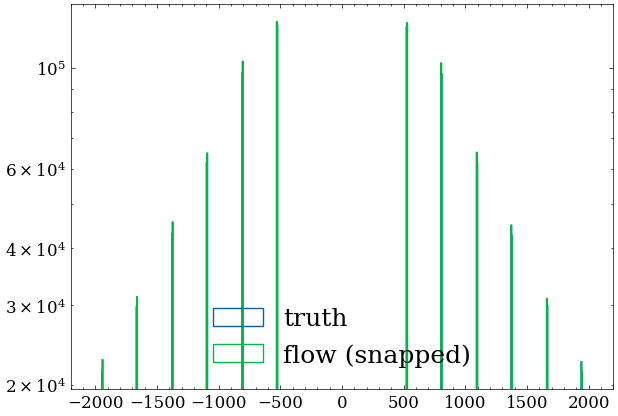

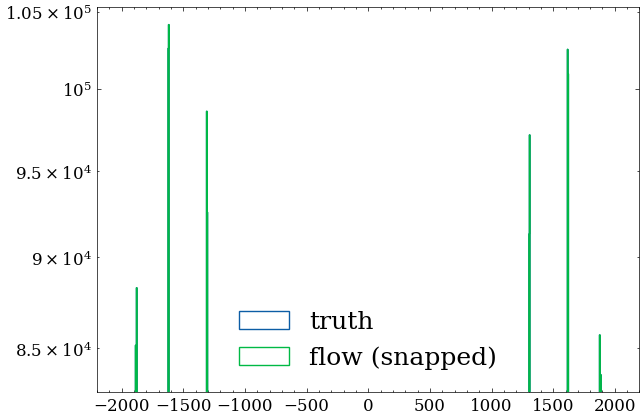

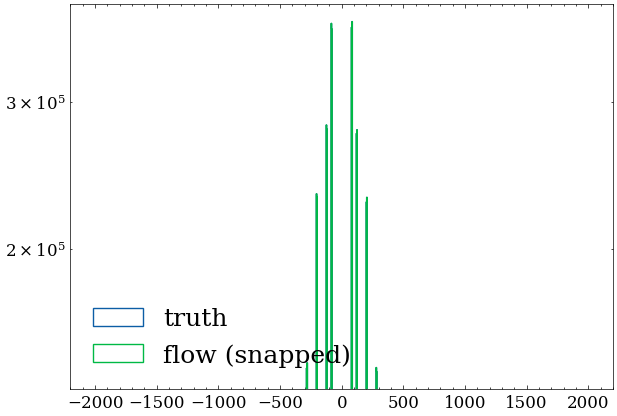

In [5]:



for col_name in collections:

    if "Endcap" in col_name:
        plt.figure()
    
        z_idx = feature_indices_dict[col_name]["z"]
        side_idx = feature_indices_dict[col_name]["side"]
        layer_idx = feature_indices_dict[col_name]["layer"]
        sensor_idx = feature_indices_dict[col_name]["sensor"]
    
        # original samples
        z_samples = all_samples_dir[col_name][:, z_idx]
        sides = all_samples_dir[col_name][:, side_idx]
        layers = all_samples_dir[col_name][:, layer_idx]
        sensors = all_samples_dir[col_name][:, sensor_idx]
    
    
        
        z_lookup = build_z_lookup(
            all_data_dir[col_name],
            feature_indices_dict[col_name]["side"],
            feature_indices_dict[col_name]["layer"],
            feature_indices_dict[col_name]["sensor"],
            feature_indices_dict[col_name]["z"],
        )
        # # snap z to detector geometry
        z_samples_snapped = snap_z_to_detector(
            z_samples, sides, layers, sensors, z_lookup
        
        )

        all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]] = z_samples_snapped
    
        # plot truth vs snapped samples
        plt.hist(
            all_data_dir[col_name][:, z_idx],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="truth"
        )
    
        plt.hist(
            z_samples_snapped,
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="flow (snapped)"
        )
    
        plt.yscale("log")
        plt.legend()
        plt.show()

In [6]:
# for col_name in collections:

#     print(col_name)

#     plot_hists_1d(
#         {"data": all_data_dir[col_name], "samples": all_samples_dir[col_name]},
#         bins_dict[col_name],
#         log_dims=log_vars,
#         labels=feature_labels_dict[col_name]
#     )
#     plt.savefig(f"figures/{col_name}_1d.png")

#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.cos(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
#             np.sin(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
#         )
#     }

#     make_2d_plots(loc_array, ["x", "y"])

#     loc_array = {
#         "data": (
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_data_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         ),
#         "samples": (
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
#             all_samples_dir[col_name][:, feature_indices_dict[col_name]["z"]]
#         )
#     }

#     make_2d_plots(loc_array, ["r", "z"])

In [7]:
"""
for col_name in collections:
    fig_samp, axes_samp = plot_corner_hist_2d(
       all_samples_dir[col_name],
        feature_labels=feature_labels,
        bins_dict=bins_dict[col_name],
        log_dims=log_vars,
        title= "flow_samples",
    )
    plt.savefig(f"figures/{col_name}_2d.png")
"""


'\nfor col_name in collections:\n    fig_samp, axes_samp = plot_corner_hist_2d(\n       all_samples_dir[col_name],\n        feature_labels=feature_labels,\n        bins_dict=bins_dict[col_name],\n        log_dims=log_vars,\n        title= "flow_samples",\n    )\n    plt.savefig(f"figures/{col_name}_2d.png")\n'

In [8]:
flow_samples_masked, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir, collections, NUM_COND_INPUTS, feature_indices_dict)




InnerTrackerBarrelCollection: 59.75358846068816% of samples pass (2346043, 3926196)
InnerTrackerEndcapCollection: 99.79178524028615% of samples pass (1611317, 1614679)
OuterTrackerBarrelCollection: 53.43105906766833% of samples pass (1752901, 3280678)
OuterTrackerEndcapCollection: 99.8164855968482% of samples pass (1463135, 1465825)
VertexBarrelCollection: 96.30893035113279% of samples pass (2050577, 2129166)
VertexEndcapCollection: 99.79269455818333% of samples pass (4087879, 4096371)
alpha = 0.058823529411764705
InnerTrackerBarrelCollection (2346043, 9) (226693, 9)
InnerTrackerEndcapCollection (1611317, 9) (94427, 9)
OuterTrackerBarrelCollection (1752901, 9) (162728, 9)
OuterTrackerEndcapCollection (1463135, 9) (85683, 9)
VertexBarrelCollection (2050577, 9) (125023, 9)
VertexEndcapCollection (4087879, 9) (240842, 9)


InnerTrackerBarrelCollection


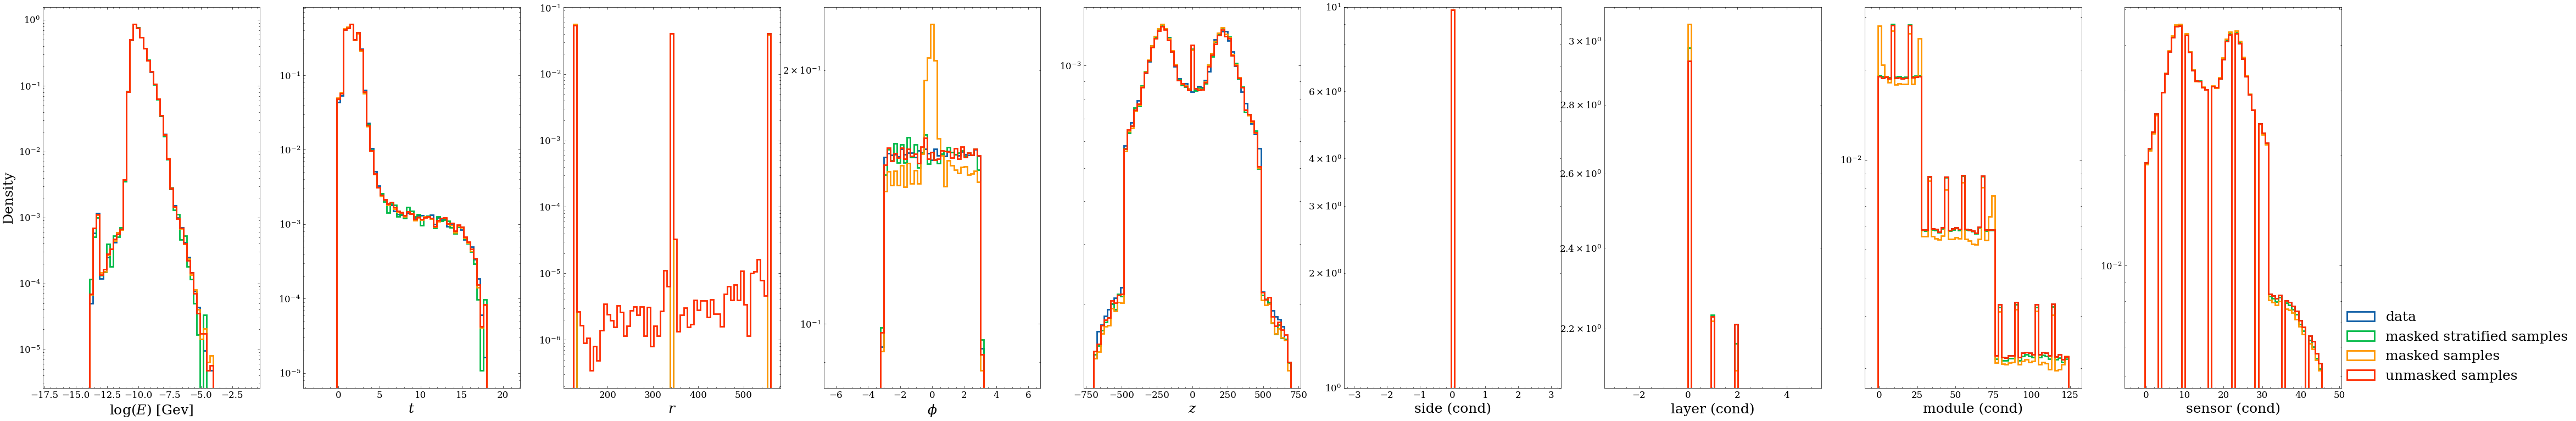

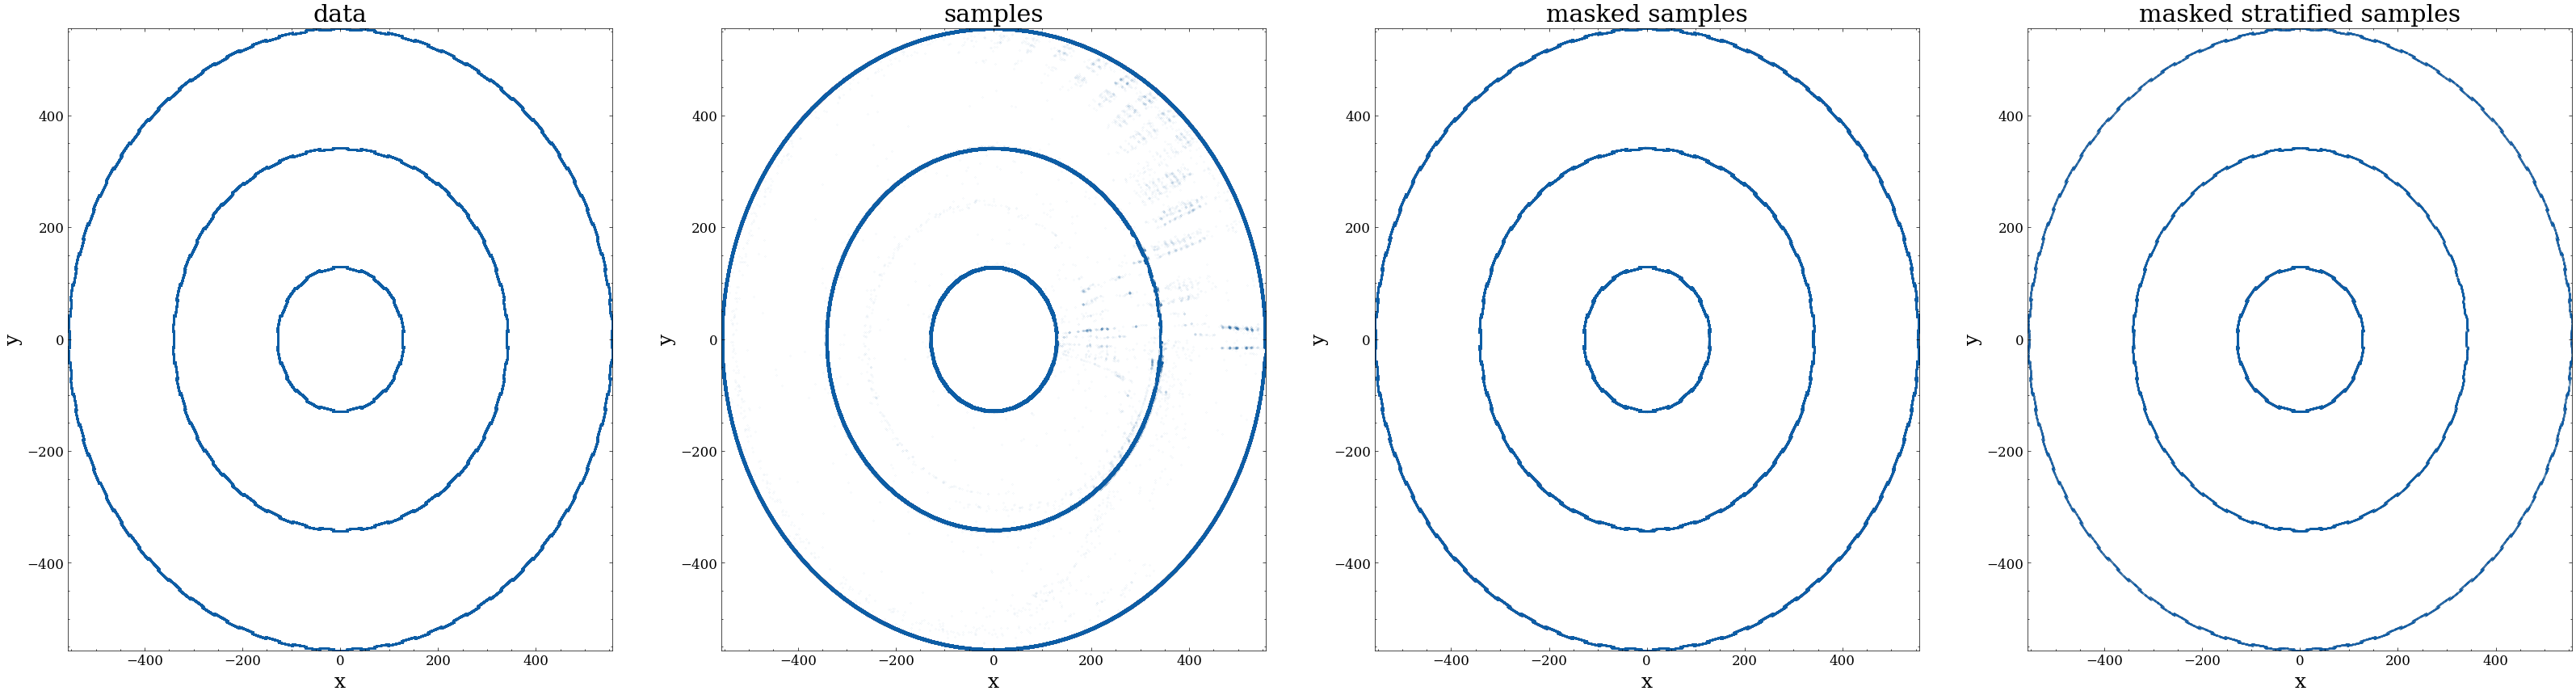

InnerTrackerEndcapCollection


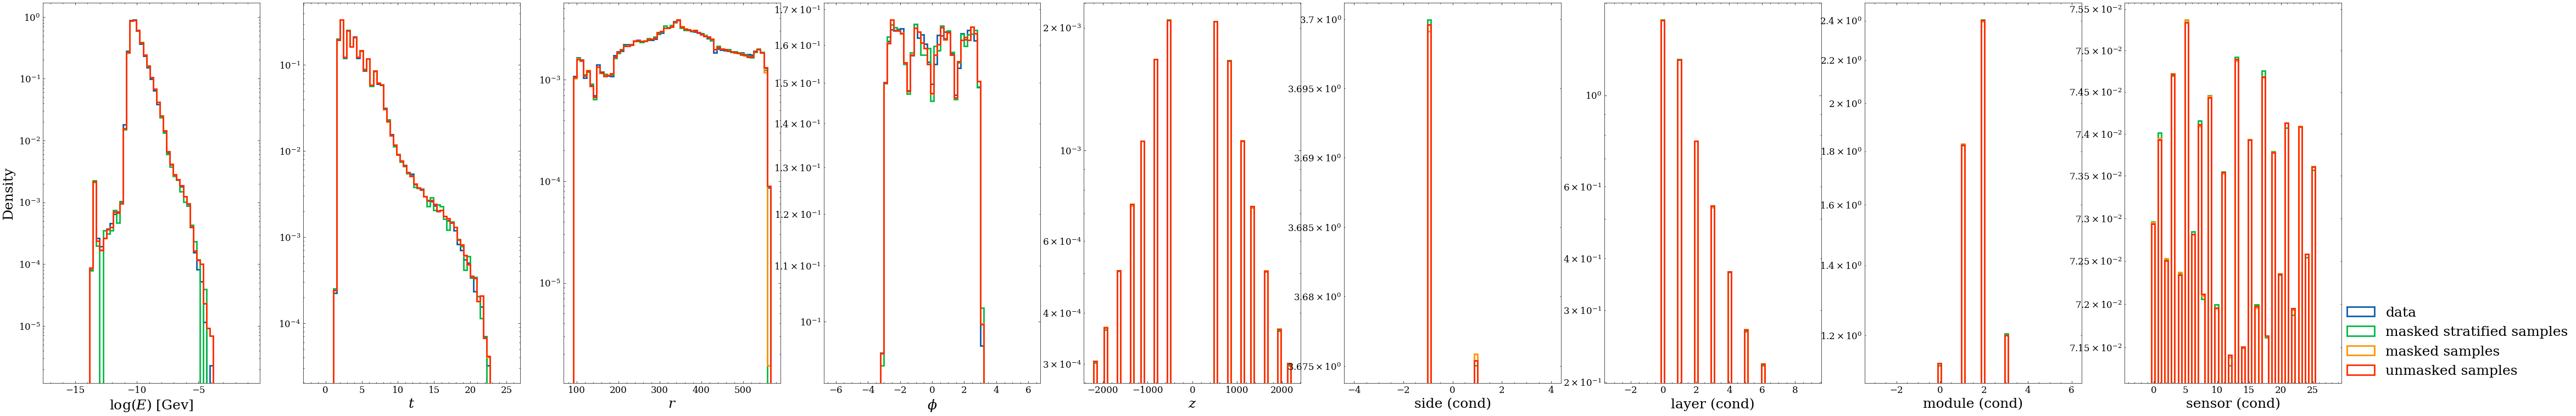

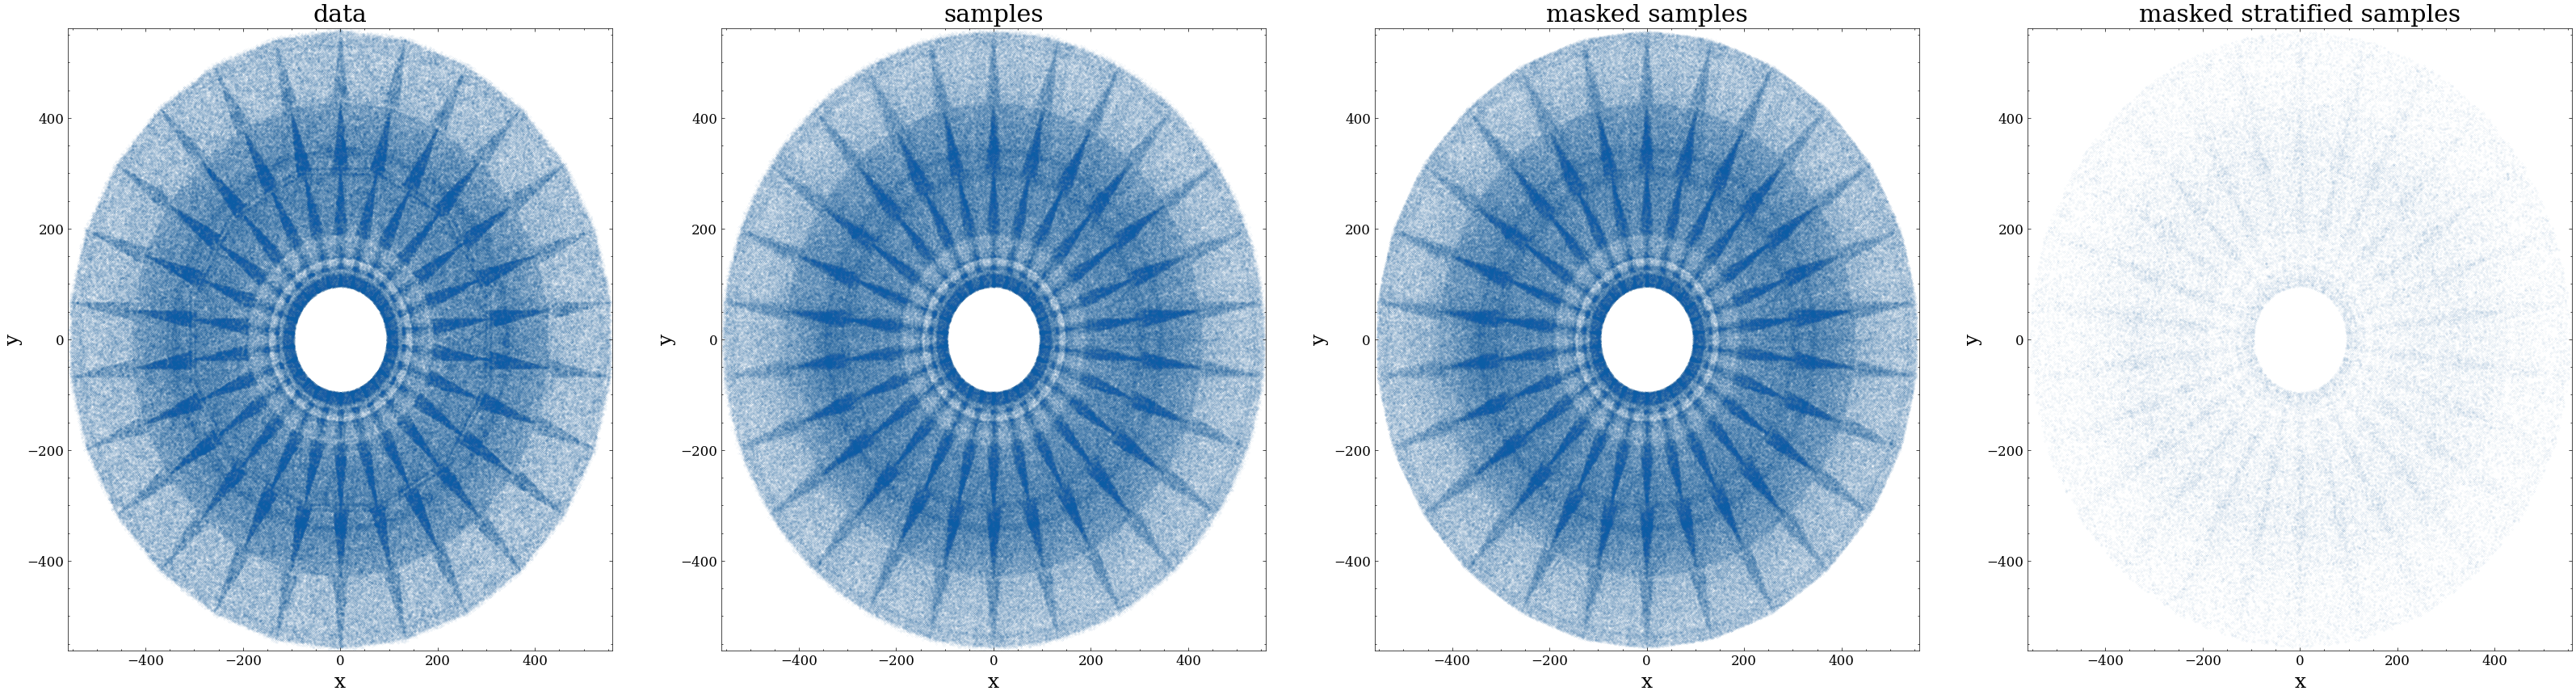

OuterTrackerBarrelCollection


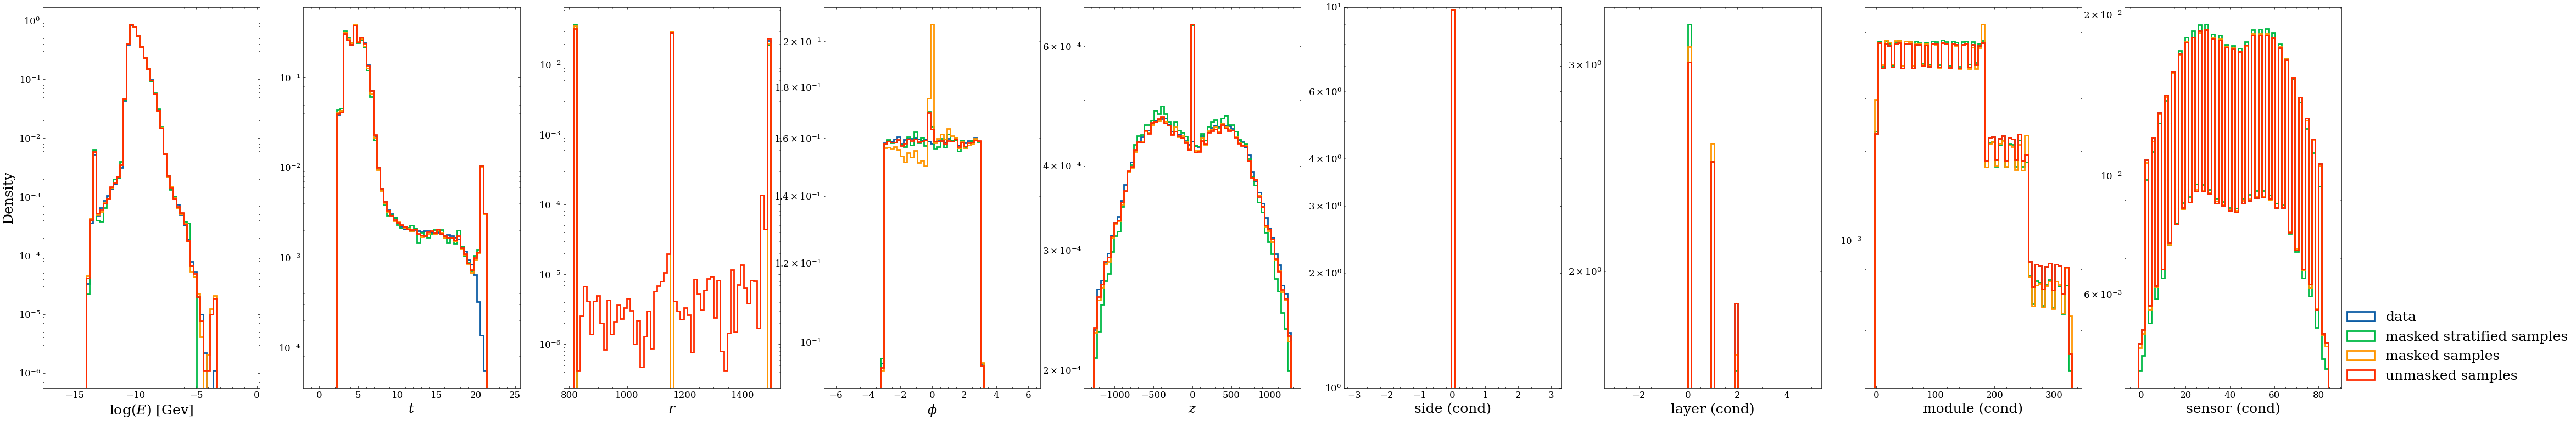

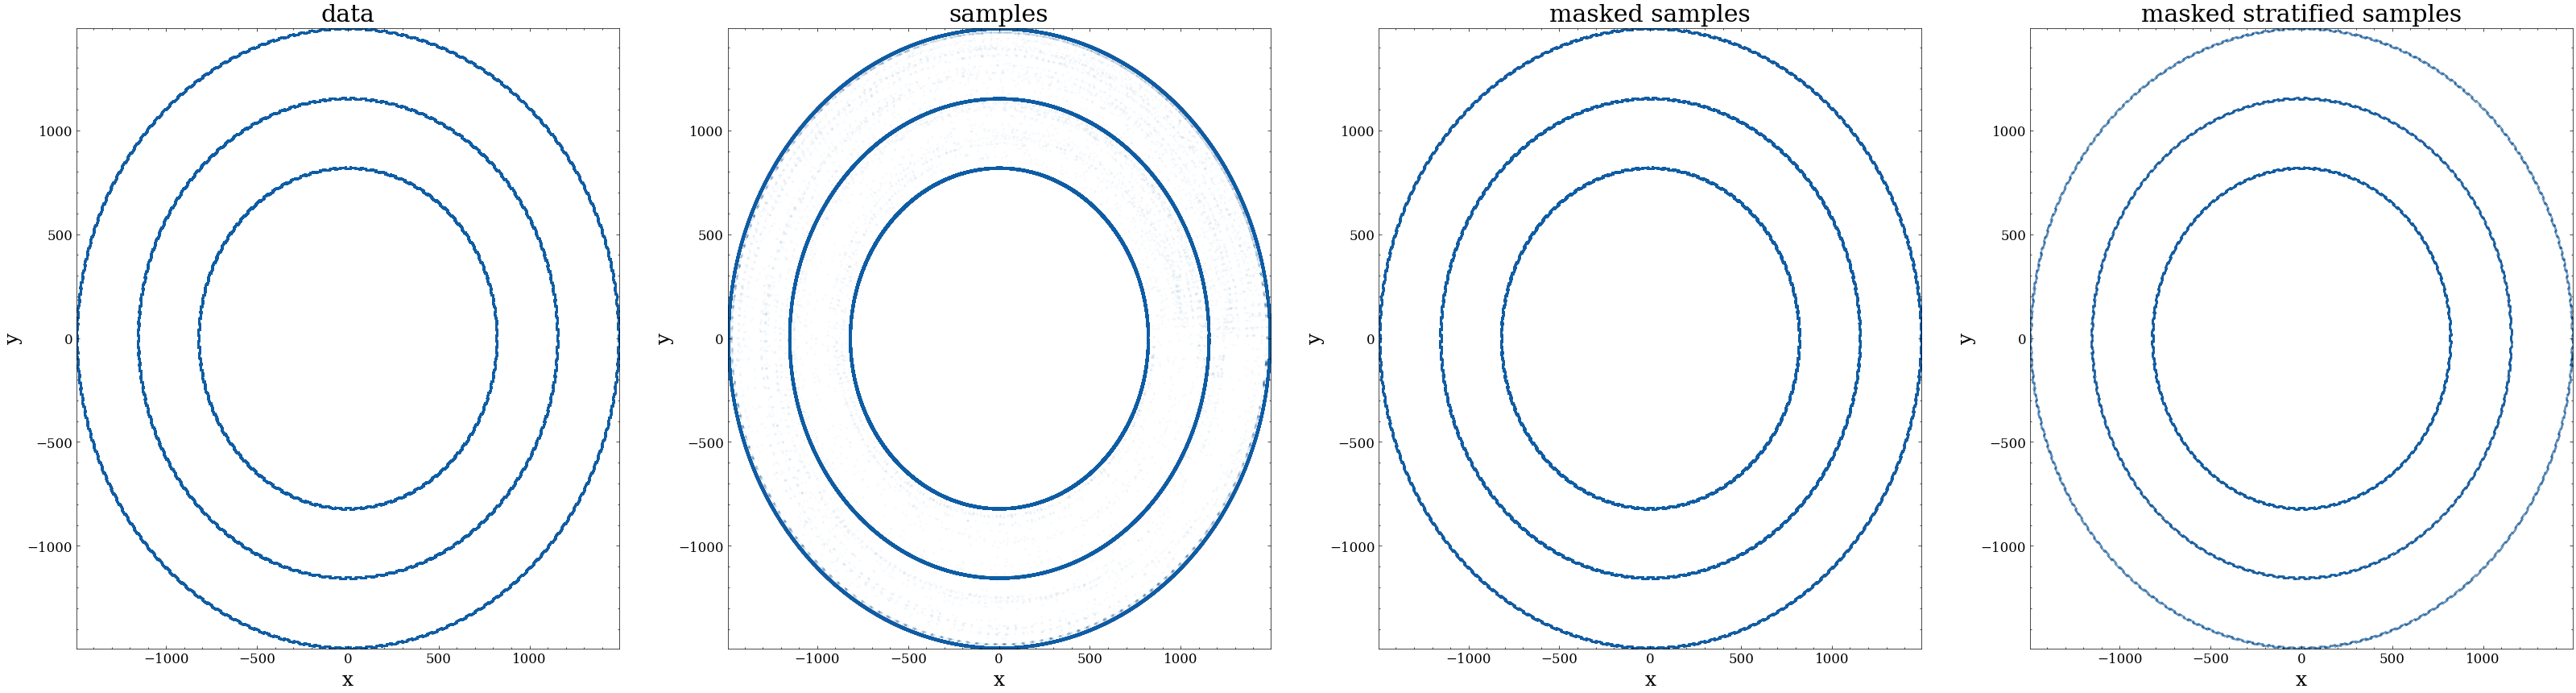

OuterTrackerEndcapCollection


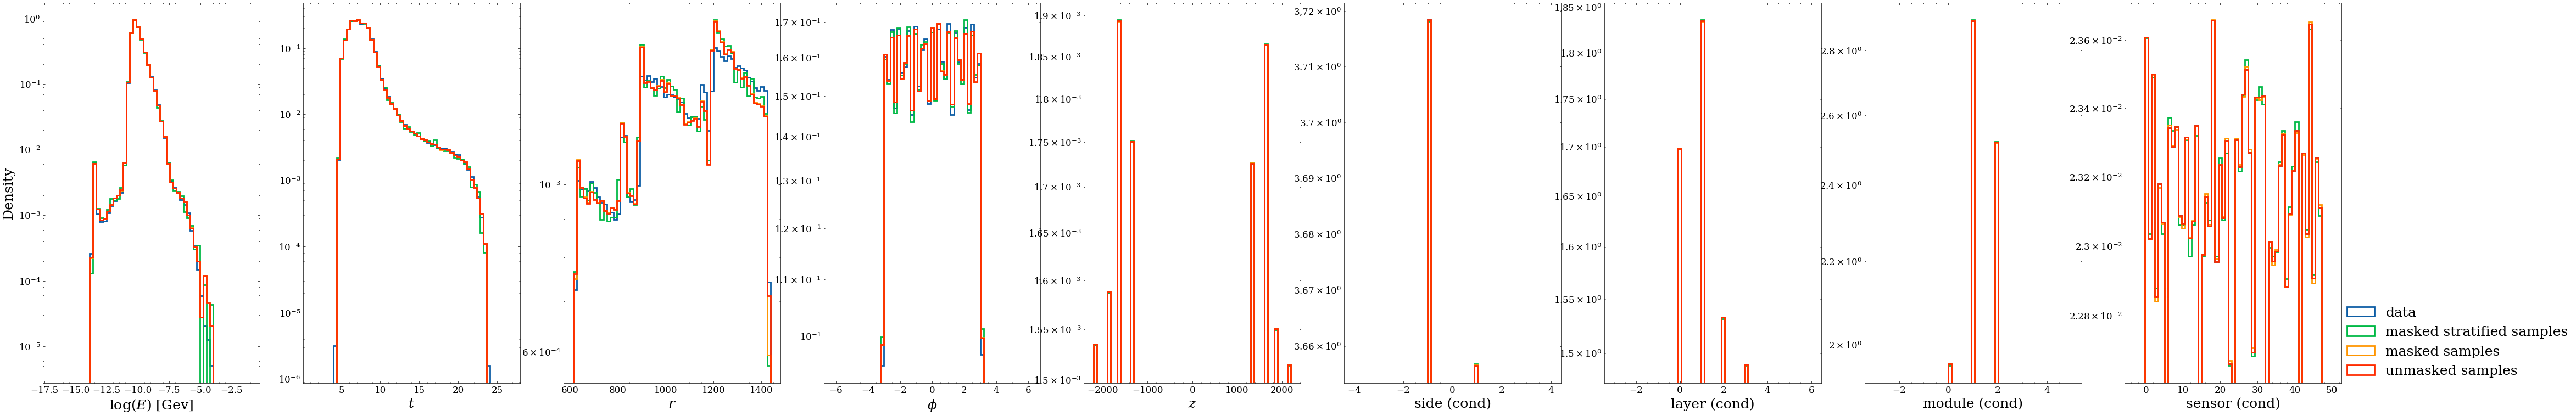

In [ ]:


for i, col_name in enumerate(collections):

    print(col_name)
    
    
    plot_hists_1d({
        "data":all_data_dir[col_name], 
        "unmasked samples":  all_samples_dir[col_name],
        "masked samples": flow_samples_masked[col_name],
         "masked stratified samples": flow_samples_masked_stratified[col_name],
    }, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)
    plt.savefig(f"figures/{col_name}_1d.png")


    
    loc_array = {
        "data": (
            all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.cos(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
            all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.sin(all_data_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
        ),
        "samples": (
            all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.cos(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]]),
            all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.sin(all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]])
        ),
        "masked samples": (
            flow_samples_masked[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.cos(flow_samples_masked[col_name][:, feature_indices_dict[col_name]["phi"]]),
            flow_samples_masked[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.sin(flow_samples_masked[col_name][:, feature_indices_dict[col_name]["phi"]])
        ),
        "masked stratified samples": (
            flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.cos(flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["phi"]]),
            flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["r"]] *
            np.sin(flow_samples_masked_stratified[col_name][:, feature_indices_dict[col_name]["phi"]])
        )
    }

    make_2d_plots(loc_array, ["x", "y"])

    # loc_array = {
    #     "data": (
    #         all_data_dir[col_name][:, feature_indices_dict[col_name]["r"]],
    #         all_data_dir[col_name][:, feature_indices_dict[col_name]["z"]]
    #     ),
    #     "samples": (
    #         all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
    #         all_samples_dir[col_name][:, feature_indices_dict[col_name]["z"]]
    #     ),
    #     "masked samples": (
    #         all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["r"]],
    #         all_samples_dir[col_name][mask][:, feature_indices_dict[col_name]["z"]]
    #     )
    # }

    # make_2d_plots(loc_array, ["r", "z"])

In [ ]:
single_bdt_results, all_scores, all_plot = {}, {}, {}

import torch
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)


for col_name in collections:

    print(f"Analyzing {col_name}...")

    
    


    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(all_data_dir[col_name][:,i])), np.log10(1.1*np.max(all_data_dir[col_name][:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(all_data_dir[col_name][:,i] - 3), np.max(all_data_dir[col_name][:,i] + 3), NUM_BINS) 
    
    #indices_1 = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    #indices_2 = np.random.choice(all_samples_dir[col_name].shape[0], size=N, replace=False)
    

    N = flow_samples_masked_stratified[col_name].shape[0]

    
    indices_data = np.random.choice(all_data_dir[col_name].shape[0], size=N, replace=False)
    indices_flow = np.random.choice(flow_samples_masked[col_name].shape[0], size=N, replace=False)

    tmp = run_eval_suite_BDTs(all_data_dir[col_name][indices_data], 
                              {
                                  "masked":flow_samples_masked[col_name][indices_flow], 
                               "masked_stratified":flow_samples_masked_stratified[col_name]
                              },
                                bins_dict[col_name],
                              n_cond = NUM_COND_INPUTS,
                                device=device,
                                num_BDTs=num_BDTs,
                                plot_suffix=f"_{col_name}",
                             feature_labels=feature_labels_dict[col_name],
                              run_single_feature_BDTs=False
                             
                             )

    single_bdt_results[col_name] = tmp[0]
    all_scores[col_name] = tmp[1]
    all_plot[col_name] = tmp[2]


  #  run_eval_suite_R(all_data_dir[col_name][indices_1], {"unmasked":all_samples_dir[col_name][indices_2], "masked":all_samples_dir[col_name][mask][indices_3]}, [0.1, 0.2, 0.4],  100, plot_suffix="")
#
    


In [ ]:
single_bdt_results, all_scores, all_plot = {}, {}, {}

total_data = []
total_samples = []
          
for col_name in collections:

    mask = apply_material_map_hybrid(all_samples_dir, None, col_name, feature_indices_dict)

    total_data.append(all_data_dir[col_name][mask])
    total_samples.append(all_samples_dir[col_name][mask])

    
total_data = np.concatenate(total_data, axis = 0)
total_samples = np.concatenate(total_samples, axis = 0)
print(total_data.shape, total_samples.shape)

   
N = 1_000_000




indices_3 = np.random.choice(total_data.shape[0], size=N, replace=False)

tmp = run_eval_suite_BDTs(total_data[indices_3], 
                          {
                              #"unmasked":all_samples_dir[col_name][indices_2], 
                           "masked":total_samples[indices_3]
                          },
                            bins_dict[col_name],
                          n_cond = NUM_COND_INPUTS,
                            device=device,
                            num_BDTs=num_BDTs,
                            plot_suffix=f"_{col_name}",
                         feature_labels=feature_labels_dict[col_name],
                          run_single_feature_BDTs=False
                         
                         )

single_bdt_results[col_name] = tmp[0]
all_scores[col_name] = tmp[1]
all_plot[col_name] = tmp[2]



In [ ]:

plt.figure()
for i, col_name in enumerate(single_bdt_results.keys()):
    if "Barrel" in col_name:
        for key in single_bdt_results[col_name].keys():
            x_vals = single_bdt_results[col_name][key].keys()
            
            res = [single_bdt_results[col_name][key][x][0] for x in x_vals]
            res_gauss = [single_bdt_results[col_name][key][x][1] for x in x_vals]
            if key == "masked":
                plt.scatter(x_vals, res, color = f"C{i}", label = f"{col_name}, masked", marker="o", s=100)
            elif key == "unmasked":
                plt.scatter(x_vals, res, edgecolor = f"C{i}", label = f"{col_name}, unmasked", marker="o", s=100, facecolor="none")
plt.legend(loc=(1,0))
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8], labels = feature_labels_dict[col_name], rotation = 45)
plt.xlabel("feature")

plt.ylabel("ROC AUC")
plt.show()

# Analyzing the features that didn't pass

In [ ]:
col_to_analyze = "OuterTrackerEndcapCollection"
percentile_to_analyze = 90

passes =  np.array(all_scores[col_to_analyze]["masked"] >= np.percentile(all_scores[col_to_analyze]["unmasked"], percentile_to_analyze))


fig, ax = plt.subplots(1, all_plot[col_to_analyze]["masked"].shape[1], figsize = (30, 5))
for i in range(all_plot[col_to_analyze]["masked"].shape[1]):
    ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][~passes], histtype = "step", color = "green", bins = bins_dict[col_to_analyze][i])
    ax[i].hist(all_plot[col_to_analyze]["masked"][:,i][passes], histtype = "step", color = "red", bins = bins_dict[col_to_analyze][i])
    ax[i].set_xlabel(feature_labels_dict[col_to_analyze][i])
plt.show()




plt.figure(figsize = (10, 10))
x = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.cos(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
y = all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["r"]]*np.sin(all_plot[col_to_analyze]["masked"][:,feature_indices_dict[col_to_analyze]["phi"]])
plt.scatter(x[~passes], y[~passes], color = "green", s = 0.1, label = f"below {percentile_to_analyze} percentile")
plt.scatter(x[passes], y[passes], color = "red", s = 0.1, label = f"above {percentile_to_analyze} percentile")
plt.title(f"{col_to_analyze}\nred: above {percentile_to_analyze} percentile")
plt.show()





In [ ]:
bb = np.linspace(-1621.855, -1621.8478, 500)

plt.figure(figsize = (10, 4))
plt.hist(all_data_dir[col_name][:,feature_indices_dict[col_name]["z"]], bins = bb, density = True, label = "data", histtype = "stepfilled")



for p in [50]:
    #tmp_masked =  all_plot[col_name]["masked"][all_scores[col_name]["masked"] >= np.percentile(all_scores[col_name]["masked"], p)]
    tmp_unmasked =  all_plot[col_name]["unmasked"][all_scores[col_name]["unmasked"] >= np.percentile(all_scores[col_name]["unmasked"], p)]
    plt.hist(tmp_unmasked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "bad", color = "red")

    tmp_unmasked =  all_plot[col_name]["unmasked"][all_scores[col_name]["unmasked"] <= np.percentile(all_scores[col_name]["unmasked"], p)]
    plt.hist(tmp_unmasked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "good", color = "green")

    plt.axvline(-1621.8538551980234)
    plt.axvline(-1621.8496531597395)
    
   # plt.hist(tmp_masked[:,feature_indices_dict[col_name]["z"]], bins = bb, histtype = "step", density = True, label = "masked")
plt.legend()
plt.yscale("log")
plt.show()

In [ ]:
bins = 1000
for col_name in collections:

    print(col_name)

    plt.figure(figsize = (10, 10))

    plt.hist2d(all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.cos(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]]), 
               all_data_dir[col_name][:,feature_indices_dict[col_name]["r"]]*np.sin(all_data_dir[col_name][:,feature_indices_dict[col_name]["phi"]]), 
               bins=(bins,bins),
              norm="log",)
    plt.show()
   